Vectorized model loaded from vectorized_results_discrete_high_penalty
Running Value Iteration...
Value Iteration converged at iteration 833


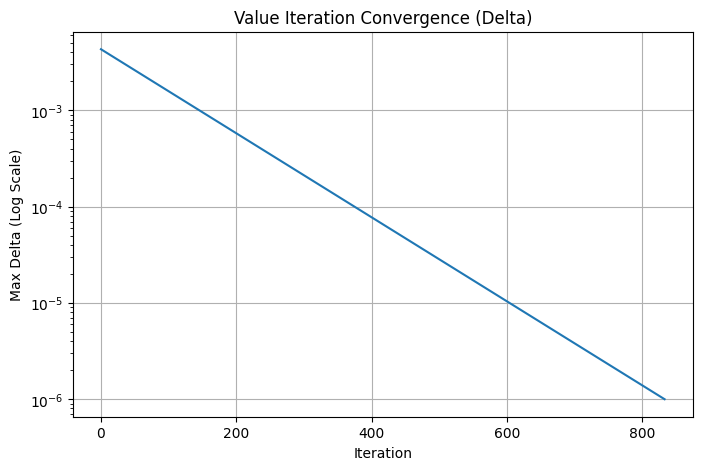

In [2]:
import numpy as np
import gymnasium as gym
from scipy.sparse import lil_matrix, csr_matrix
from tqdm import tqdm
import pickle
import os
from scipy.sparse import save_npz, load_npz
import cv2
import matplotlib.pyplot as plt

class VectorizedStochasticCartPole:
    def __init__(self, bins_per_dim=10):
        self.env = gym.make('CartPole-v1')
        # Define bins
        self.bins = [np.linspace(-2.4, 2.4, bins_per_dim),
                     np.linspace(-3.0, 3.0, bins_per_dim),
                     np.linspace(-0.21, 0.21, bins_per_dim),
                     np.linspace(-3.5, 3.5, bins_per_dim)]
        
        self.state_sizes = [len(b) + 1 for b in self.bins]
        self.num_states = int(np.prod(self.state_sizes))
        self.gamma = 0.99
        
        # Sparse Transition Matrices: P[action] is (N x N)
        # lil_matrix is efficient for construction
        self.P = [lil_matrix((self.num_states, self.num_states)) for _ in range(2)]
        self.R = np.zeros((self.num_states, 2))
        self.V = np.zeros(self.num_states)
        # Policy: Probability of taking action 0 for each state
        self.pi0 = np.ones(self.num_states) * 0.5

        # History to track convergence
        self.delta_history = []

    def get_index(self, obs):
        indices = tuple(np.digitize(obs[i], self.bins[i]) for i in range(4))
        return np.ravel_multi_index(indices, self.state_sizes)

    def build_model(self, k_samples=20):
        print("Building Vectorized Stochastic Model...")
        for s_idx in tqdm(range(self.num_states)):
            # To be truly vectorized, you'd sample all k_samples at once, 
            # but setting env.state must happen sequentially.
            multi_idx = np.unravel_index(s_idx, self.state_sizes)
            
            for a in range(2):
                counts = {}
                total_r = 0
                for _ in range(k_samples):
                    # Sample point in bin
                    c_state = [np.random.uniform(self.bins[i][idx-1] if idx > 0 else -3, 
                                                 self.bins[i][idx] if idx < len(self.bins[i]) else 3) 
                               for i, idx in enumerate(multi_idx)]
                    
                    self.env.reset()
                    self.env.unwrapped.state = np.array(c_state)
                    obs, reward, term, trunc, _ = self.env.step(a)
                    
                    s_next = self.get_index(obs)
                    counts[s_next] = counts.get(s_next, 0) + 1

                    if term:
                        reward = -100 
                    else:
                        # Your modified reward: (1 - x^2 - theta^2)
                        # obs[0] is cart position, obs[2] is pole angle
                        reward = 1.0 - 10*(obs[0]**2) - 10*(obs[2]**2)
                    
                    total_r += reward
                
                # Fill sparse matrix
                for s_next, count in counts.items():
                    self.P[a][s_idx, s_next] = count / k_samples
                self.R[s_idx, a] = total_r / k_samples
        
        # Convert to CSR for fast math operations
        self.P = [p.tocsr() for p in self.P]

    def value_iteration(self, theta=1e-6, max_iterations=1000):
        """
        Performs Value Iteration.
        Directly updates V by taking the max over actions.
        """
        print("Running Value Iteration...")
        for i in range(max_iterations):
            delta = 0
            
            # Calculate Q-values for all actions simultaneously using sparse matrices
            # Q0 and Q1 are vectors of shape (num_states,)
            Q0 = self.R[:, 0] + self.gamma * self.P[0].dot(self.V)
            Q1 = self.R[:, 1] + self.gamma * self.P[1].dot(self.V)
            
            # The new Value function is the element-wise maximum of the Q-values
            new_V = np.maximum(Q0, Q1)
            
            # Check for convergence
            delta = np.max(np.abs(new_V - self.V))
            self.delta_history.append(delta)
            self.V = new_V
            
            if delta < theta:
                print(f"Value Iteration converged at iteration {i}")
                break
                
        # After V converges, derive the final optimal policy (pi0)
        Q0 = self.R[:, 0] + self.gamma * self.P[0].dot(self.V)
        Q1 = self.R[:, 1] + self.gamma * self.P[1].dot(self.V)
        self.pi0 = (Q0 >= Q1).astype(float)

    def train(self):
        self.value_iteration()
        self.plot_convergence(self.delta_history, "Value Iteration Convergence (Delta)")

    def plot_convergence(self, history, title):
        """Used for Model-Based Delta tracking"""
        plt.figure(figsize=(8, 5))
        plt.plot(history)
        plt.yscale('log') # Log scale helps see convergence at small values
        plt.title(title)
        plt.xlabel("Iteration")
        plt.ylabel("Max Delta (Log Scale)")
        plt.grid(True)
        plt.show()
    
    def save_model(self, folder="vectorized_model"):
        """Saves the policy, bins, and sparse transition matrices."""
        if not os.path.exists(folder):
            os.makedirs(folder)
            
        # Save the metadata and policy
        metadata = {
            'pi0': self.pi0,
            'bins': self.bins,
            'state_sizes': self.state_sizes,
            'R': self.R,
            'V': self.V
        }
        with open(f"{folder}/metadata.pkl", 'wb') as f:
            pickle.dump(metadata, f)
            
        # Save Sparse Matrices efficiently
        save_npz(f"{folder}/P0.npz", self.P[0])
        save_npz(f"{folder}/P1.npz", self.P[1])
        print(f"Vectorized model saved to folder: {folder}")

    def load_model(self, folder="vectorized_model"):
        """Loads the policy and sparse matrices."""
        with open(f"{folder}/metadata.pkl", 'rb') as f:
            metadata = pickle.load(f)
            
        self.pi0 = metadata['pi0']
        self.bins = metadata['bins']
        self.state_sizes = metadata['state_sizes']
        self.R = metadata['R']
        self.V = metadata['V']
        
        self.P = [
            load_npz(f"{folder}/P0.npz"),
            load_npz(f"{folder}/P1.npz")
        ]
        print(f"Vectorized model loaded from {folder}")

    def record_performance(self, video_folder="vec_cartpole_videos", num_episodes=3):
        """Records the agent's behavior."""
        # We use rgb_array for recording
        env = gym.make('CartPole-v1', render_mode="rgb_array")
        env = gym.wrappers.RecordVideo(
            env, 
            video_folder, 
            episode_trigger=lambda ep: True,
            name_prefix="vectorized-agent"
        )

        for ep in range(num_episodes):
            obs, _ = env.reset()
            done = False
            score = 0
            
            while not done:
                s_idx = self.get_index(obs)
                # In vectorized mode, pi0[s_idx] is 1.0 for Action 0, 0.0 for Action 1
                action = 0 if self.pi0[s_idx] > 0.5 else 1
                
                obs, reward, terminated, truncated, _ = env.step(action)
                done = terminated or truncated
                score += reward
                
            print(f"Recorded Episode {ep}: Score = {score}")
        
        env.close()

    def create_concatenated_video(self, output_name="agent_performance.mp4", num_episodes=1):
        # 1. Setup Environment and Video Writer
        env = gym.make('CartPole-v1', render_mode="rgb_array")
        
        # Get frame dimensions from a dummy reset
        obs, _ = env.reset()
        frame = env.render()
        height, width, layers = frame.shape
        
        # Define video codec and writer (24 FPS is standard for smooth playback)
        fourcc = cv2.VideoWriter_fourcc(*'mp4v') 
        video = cv2.VideoWriter(output_name, fourcc, 24, (width, height))

        print(f"Recording {num_episodes} episodes to {output_name}...")

        for ep in range(1, num_episodes + 1):
            obs, _ = env.reset()
            done = False
            score = 0
            step = 0
            
            while not done:
                # 2. Get Action from Agent
                s_idx = self.get_index(obs)
                # Works for both Dictionary (policy[s_idx] is dict) or Vectorized (pi0[s_idx] is float)
                if hasattr(self, 'pi0'): # Vectorized check
                    action = 0 if self.pi0[s_idx] > 0.5 else 1
                else: # Dictionary check
                    action = np.argmax(self.policy[s_idx])

                # 3. Step Environment
                obs, reward, terminated, truncated, _ = env.step(action)
                done = terminated or truncated
                score += reward
                step += 1

                # 4. Capture and Process Frame
                frame = env.render()
                # Convert RGB (Gym) to BGR (OpenCV)
                frame_bgr = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)

                # 5. Overlay Text Data (Top-left corner, stacked)
                font = cv2.FONT_HERSHEY_SIMPLEX
                font_scale = 0.5  # Smaller letters
                font_thickness = 1
                color = (0, 0, 0)  # White
                x_offset = 15  # Distance from left edge

                # Define each line's content and its Y-coordinate
                lines = [
                    (f"Episode: {ep}", 25),
                    (f"Score: {int(score)}", 45),
                    (f"Step: {step}", 65)
                ]

                # Draw a small translucent background box for the corner
                cv2.rectangle(frame_bgr, (5, 5), (150, 75), (255, 255, 255), -1)

                for text, y_pos in lines:
                    cv2.putText(
                        frame_bgr, 
                        text, 
                        (x_offset, y_pos), 
                        font, 
                        font_scale, 
                        color, 
                        font_thickness, 
                        cv2.LINE_AA
                    )

                # 6. Write to Video
                video.write(frame_bgr)

            print(f"Finished Episode {ep} with Score: {score}")

        # Finalize
        video.release()
        env.close()
        print(f"Video saved as {output_name}")

# 1. Initialize
vec_agent = VectorizedStochasticCartPole(bins_per_dim=16)

# 2. Build Model
# vec_agent.build_model()

vec_agent.load_model("vectorized_results_discrete_high_penalty")

# 3. Train (Vectorized is much faster!)
vec_agent.train()

# 4. Save everything
# vec_agent.save_model("vectorized_results_discrete_high_penalty")

# # 5. Record the agent in action
# vec_agent.record_performance(video_folder="eval_videos_high_penalty")
# vec_agent.load_model("vectorized_results_discrete_high_penalty")
# vec_agent.create_concatenated_video(output_name="vectorized_results_discrete_high_penalty.mp4", num_episodes=10)